# System rekomendacji win
### Porównanie modeli: NCF, Gradient Boosting, Random Forest, RP3β

## 1. Importy i konfiguracja

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt

print(sys.executable)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

c:\Users\Filip\wine_pc\wine-recommender\.venv\Scripts\python.exe
Torch version: 2.10.0+cu126
CUDA available: True
GPU name: NVIDIA GeForce RTX 2060
Using device: cuda


## 2. Wczytanie i podział danych

In [2]:
df = pd.read_csv('data\\XWines_Slim_150K_ratings.csv')
df = df[["Rating", "UserID", "WineID", "Date"]]
df.sort_values("Date", ascending=True, inplace=True)
df.reset_index(drop=True, inplace=True)

split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

X_train = train_df[["UserID", "WineID", "Date"]]
y_train = train_df["Rating"]
X_test  = test_df[["UserID", "WineID", "Date"]].copy()
y_test  = test_df["Rating"]

print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

Train size: 120000, Test size: 30000


C:\Users\Filip\AppData\Local\Temp\ipykernel_14036\2572918404.py:1: DtypeWarning: Columns (0: Vintage) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data\\XWines_Slim_150K_ratings.csv')


## 3. Mapowanie użytkowników i win na indeksy

In [3]:
users    = X_train['UserID'].unique()
wines    = X_train['WineID'].unique()
user2_id = {u: i for i, u in enumerate(users)}
wine2_id = {w: i for i, w in enumerate(wines)}

X_train = X_train.copy()
X_train['user_idx'] = X_train['UserID'].map(user2_id)
X_train['wine_idx'] = X_train['WineID'].map(wine2_id)
X_train.dropna(inplace=True)
y_train = y_train.loc[X_train.index]

X_test['user_idx'] = X_test['UserID'].map(user2_id)
X_test['wine_idx'] = X_test['WineID'].map(wine2_id)

# usuwanie cold-start (użytkownicy/wina spoza train)
mask = X_test['user_idx'].notna() & X_test['wine_idx'].notna()
X_test_clean = X_test[mask].copy()
y_test_clean = y_test[mask].copy()

for col in ['user_idx', 'wine_idx']:
    X_train[col]      = X_train[col].astype(int)
    X_test_clean[col] = X_test_clean[col].astype(int)

num_users = len(user2_id)
num_wines = len(wine2_id)
print(f"Liczba użytkowników: {num_users}, Liczba win: {num_wines}")
print(f"Cold-start usunięto: {(~mask).sum()} rekordów")

Liczba użytkowników: 10357, Liczba win: 1000
Cold-start usunięto: 1800 rekordów


## 4. Konwersja do tensorów i DataLoader

In [4]:
X_user_train = torch.tensor(X_train['user_idx'].values, dtype=torch.long)
X_wine_train = torch.tensor(X_train['wine_idx'].values, dtype=torch.long)
y_train_t    = torch.tensor(y_train.values, dtype=torch.float32)

X_user_test = torch.tensor(X_test_clean['user_idx'].values, dtype=torch.long)
X_wine_test = torch.tensor(X_test_clean['wine_idx'].values, dtype=torch.long)
y_test_t    = torch.tensor(y_test_clean.values, dtype=torch.float32)

batch_size    = 2048
train_loader  = DataLoader(TensorDataset(X_user_train, X_wine_train, y_train_t),
                           batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=2)
test_loader   = DataLoader(TensorDataset(X_user_test, X_wine_test, y_test_t),
                           batch_size=batch_size, pin_memory=True, num_workers=2)

## 5. Definicja metryk

In [5]:
def calculate_regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

def precision_at_k(y_true, y_pred, k=10, threshold=4.0):
    sorted_indices = np.argsort(y_pred)[::-1][:k]
    return np.sum(y_true[sorted_indices] >= threshold) / k

def recall_at_k(y_true, y_pred, k=10, threshold=4.0):
    sorted_indices   = np.argsort(y_pred)[::-1][:k]
    total_relevant   = np.sum(y_true >= threshold)
    relevant_in_topk = np.sum(y_true[sorted_indices] >= threshold)
    return relevant_in_topk / total_relevant if total_relevant > 0 else 0

def ndcg_at_k(y_true, y_pred, k=10):
    def dcg_at_k(r, k):
        r = np.asarray(r, dtype=np.float64)[:k]
        return np.sum(r / np.log2(np.arange(2, r.size + 2))) if r.size else 0.
    sorted_indices = np.argsort(y_pred)[::-1][:k]
    ideal_indices  = np.argsort(y_true)[::-1][:k]
    ideal_dcg      = dcg_at_k(y_true[ideal_indices], k)
    return dcg_at_k(y_true[sorted_indices], k) / ideal_dcg if ideal_dcg > 0 else 0

def calculate_ranking_metrics_per_user(X_test_df, y_test_array, y_pred_array, k=10):
    X_test_df = X_test_df.copy()
    X_test_df['y_true'] = y_test_array
    X_test_df['y_pred'] = y_pred_array

    precision_scores, recall_scores, ndcg_scores = [], [], []

    for user_id in X_test_df['user_idx'].unique():
        user_data = X_test_df[X_test_df['user_idx'] == user_id]
        if len(user_data) < k:
            continue
        y_true_user = user_data['y_true'].values
        y_pred_user = user_data['y_pred'].values
        precision_scores.append(precision_at_k(y_true_user, y_pred_user, k))
        recall_scores.append(recall_at_k(y_true_user, y_pred_user, k))
        ndcg_scores.append(ndcg_at_k(y_true_user, y_pred_user, k))

    return {
        f'Precision@{k}': np.mean(precision_scores),
        f'Recall@{k}':    np.mean(recall_scores),
        f'NDCG@{k}':      np.mean(ndcg_scores)
    }

def calculate_coverage(model, user2_id, wine2_id, device, threshold=3.5):
    model.eval()
    recommended_wines = set()
    with torch.no_grad():
        sample_users = np.random.choice(list(user2_id.values()),
                                        min(100, len(user2_id)), replace=False)
        for user_idx in sample_users:
            users_tensor = torch.tensor([user_idx] * len(wine2_id), dtype=torch.long, device=device)
            wines_tensor = torch.tensor(list(wine2_id.values()), dtype=torch.long, device=device)
            predictions  = model(users_tensor, wines_tensor).squeeze().cpu().numpy()
            recommended_wines.update(np.where(predictions >= threshold)[0])
    return len(recommended_wines) / len(wine2_id)

def evaluate_model(model, test_loader, X_test_df, y_test_array, user2_id, wine2_id, device, model_name):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for user, wine, rating in test_loader:
            preds = model(user.to(device), wine.to(device)).squeeze().cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(rating.numpy())

    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)

    all_metrics = {
        'Model': model_name,
        **calculate_regression_metrics(all_true, all_preds),
        **calculate_ranking_metrics_per_user(X_test_df, all_true, all_preds, k=5),
        **calculate_ranking_metrics_per_user(X_test_df, all_true, all_preds, k=10),
        'Coverage': calculate_coverage(model, user2_id, wine2_id, device)
    }
    return all_metrics, all_preds

## 6. RP3β

In [6]:
from sklearn.preprocessing import normalize
def train_test_split_per_user(df, test_size=0.2, random_state=42):
    train_list, test_list = [], []
    for _, user_data in df.groupby('UserID'):
        if len(user_data) < 2:
            continue
        train_u, test_u = train_test_split(user_data, test_size=test_size, random_state=random_state)
        train_list.append(train_u)
        test_list.append(test_u)
    return pd.concat(train_list), pd.concat(test_list)

class RP3Beta:
    def __init__(self, beta=0.6, top_k=100):
        self.beta = beta
        self.top_k = top_k
        self.user_item_matrix = None
        self.S_final = None

    def fit(self, df, user_col='UserID', item_col='WineID', rating_col='Rating'):
        self.users = df[user_col].unique()
        self.items = df[item_col].unique()
        self.user2idx = {u: i for i, u in enumerate(self.users)}
        self.item2idx = {it: j for j, it in enumerate(self.items)}

        rows = df[user_col].map(self.user2idx).values
        cols = df[item_col].map(self.item2idx).values

        self.user_item_matrix = csr_matrix(
            (df[rating_col].values, (rows, cols)),
            shape=(len(self.users), len(self.items))
        )
        
        Piu = normalize(self.user_item_matrix.T, norm='l1', axis=1)
        Pui = normalize(self.user_item_matrix, norm='l1', axis=1)

        S = Piu @ Pui

        item_degrees = np.array(self.user_item_matrix.sum(axis=0)).flatten()
        
        # Obliczamy potęgę bezpiecznie (tylko dla wartości > 0)
        penalty = np.zeros_like(item_degrees, dtype=float)
        mask = item_degrees > 0
        penalty[mask] = np.power(item_degrees[mask], self.beta)
        
        # Tam gdzie stopień był 0 lub wynik to 0, ustawiamy 1 (żeby nie dzielić przez 0)
        penalty[penalty == 0] = 1.0
            
        # KROK 5: Skalowanie macierzy podobieństwa
        # Używamy multiply, bo S to macierz rzadka (sparse), 
        # a dzielenie przez wektor robimy jako mnożenie przez 1/penalty
        from scipy.sparse import diags
        inv_penalty_matrix = diags(1.0 / penalty)
        
        # S_final[i, j] = S[i, j] * (1 / penalty[j])
        self.S_final = S @ inv_penalty_matrix
        

    def get_scores(self, user_id, candidate_wine_ids = None):
        u_idx = self.user2idx.get(user_id)
        if u_idx is None: return None

        # Obliczamy "ważone" zainteresowanie dla wszystkich win
        user_profile = self.user_item_matrix[u_idx]
        scores = (user_profile @ self.S_final).toarray().flatten()

        # Jeśli mamy listę kandydatów, filtrujemy wyniki
        if candidate_wine_ids is not None:
            cand_indices = [self.item2idx[c] for c in candidate_wine_ids if c in self.item2idx]
            return scores[cand_indices]
        
        return scores


    def recommend(self, user_id, top_n=10):
            u_idx = self.user2idx.get(user_id)
            if u_idx is None: return []
            
            scores = self.get_scores(user_id)
            # Zerujemy wina, które użytkownik już ocenił
            user_already_rated = self.user_item_matrix[u_idx].indices
            scores[user_already_rated] = -np.inf
            
            top_indices = np.argsort(scores)[::-1][:top_n]
            return [(self.items[i], scores[i]) for i in top_indices]



In [ ]:
def evaluate_rp3_full(model, test_df, k=10):
    precisions, recalls, hits = [], [], []
    
    # Grupujemy wina, które użytkownik faktycznie ocenił w przyszłości (test)
    test_grouped = test_df.groupby('UserID')['WineID'].apply(set)
    
    for user_id, true_wines in test_grouped.items():
        if user_id not in model.user2idx:
            continue
            
        # Pobieramy Top-K rekomendacji (same ID win)
        recs = [item for item, _ in model.recommend(user_id, top_n=k)]
        recs_set = set(recs)
        
        # Obliczamy trafienia (część wspólna)
        intersects = len(recs_set & true_wines)
        
        precisions.append(intersects / k)
        recalls.append(intersects / len(true_wines) if len(true_wines) > 0 else 0)
        hits.append(1.0 if intersects > 0 else 0.0)
        
    return {
        f"Precision@{k}": np.mean(precisions),
        f"Recall@{k}": np.mean(recalls),
        f"HitRate@{k}": np.mean(hits)
    }

# --- URUCHOMIENIE ---

# 1. Używamy Twojego chronologicznego splitu (spójność z XGBoost!)
# train_df_rp3, test_df_rp3 = train_df, test_df 

rp3 = RP3Beta(beta=0.6)
rp3.fit(train_df) # Zakładam, że train_df to Twój 80% split po dacie

print("\nWyniki RP3β):")
results = evaluate_rp3_full(rp3, test_df, k=10)
for metric, value in results.items():
    print(f"  {metric}: {value:.4f}")

In [48]:
def evaluate_rp3_as_regression_style(model, test_df, k=10):
    """
    Ewaluacja RP3beta w stylu 'Local Ranking' - ocenia tylko te wina, 
    które są w zbiorze testowym użytkownika.
    """
    precisions, recalls, ndcgs = [], [], []
    
    # Grupujemy dane testowe
    test_grouped = test_df.groupby('UserID')
    
    for user_id, group in test_grouped:
        if user_id not in model.user2idx:
            continue
            
        true_ratings = group['Rating'].values
        wine_ids = group['WineID'].values
        
        # Pobieramy score'y z RP3beta TYLKO dla tych konkretnych win
        scores = model.get_scores(user_id, candidate_wine_ids=wine_ids)
        
        if scores is None or len(scores) < k:
            continue
            
        # Obliczamy metryki rankingowe (używając Twoich funkcji)
        precisions.append(precision_at_k(true_ratings, scores, k))
        recalls.append(recall_at_k(true_ratings, scores, k))
        ndcgs.append(ndcg_at_k(true_ratings, scores, k))
        
    return {
        'Model': 'RP3β (Graph)',
        'RMSE': np.nan, # RP3beta nie ma RMSE
        'Precision@10': np.mean(precisions),
        'Recall@10': np.mean(recalls),
        'NDCG@10': np.mean(ndcgs)
    }

# Uruchamiamy 'lokalną' ewaluację dla RP3beta
metrics_rp3_local = evaluate_rp3_as_regression_style(rp3, test_df, k=10)

## 7. Model NCF (Neural Collaborative Filtering)

In [31]:
class NCF(nn.Module):
    def __init__(self, num_users, num_wines, embedding_dim=80):
        super(NCF, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.wine_embedding = nn.Embedding(num_wines, embedding_dim)
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.wine_embedding.weight, std=0.01)

        self.layer1  = nn.Linear(embedding_dim * 2, 128)
        self.bn1     = nn.BatchNorm1d(128)
        self.layer2  = nn.Linear(128, 64)
        self.bn2     = nn.BatchNorm1d(64)
        self.layer3  = nn.Linear(64, 1)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, user, wine):
        user_emb = self.user_embedding(user)
        wine_emb = self.wine_embedding(wine)
        x = torch.cat([user_emb, wine_emb], dim=1)
        
        x = self.relu(self.bn1(self.layer1(x)))
        x = self.dropout(x)
        
        x = self.relu(self.bn2(self.layer2(x)))
        x = self.dropout(x)
        
        x = self.layer3(x)
        return x

model_ncf = NCF(num_users, num_wines, embedding_dim=50).to(device)
print(model_ncf)

NCF(
  (user_embedding): Embedding(10357, 50)
  (wine_embedding): Embedding(1000, 50)
  (layer1): Linear(in_features=100, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)


In [32]:
criterion_ncf = nn.MSELoss()
optimizer_ncf = optim.Adam(model_ncf.parameters(), lr=0.003, weight_decay=1e-4)
scheduler_ncf = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ncf, mode='min', factor=0.5, patience=2)

best_loss_ncf, patience_ncf, counter_ncf = float('inf'), 5, 0

for epoch in range(20):
    # --- FAZA UCZENIA (Tylko Train) ---
    model_ncf.train()
    train_loss = 0
    for user, wine, rating in train_loader:
        user, wine, rating = user.to(device), wine.to(device), rating.to(device)
        optimizer_ncf.zero_grad()
        loss = criterion_ncf(model_ncf(user, wine).squeeze(), rating)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ncf.parameters(), max_norm=1.0)
        optimizer_ncf.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # --- FAZA WALIDACJI (Tylko Test) ---
    model_ncf.eval()
    test_loss = 0
    with torch.no_grad():
        for user, wine, rating in test_loader: # <--- TU WRACA TEST_LOADER
            user, wine, rating = user.to(device), wine.to(device), rating.to(device)
            test_loss += criterion_ncf(model_ncf(user, wine).squeeze(), rating).item()
    test_loss /= len(test_loader) # <--- DZIELIMY PRZEZ TEST_LOADER

    # Dalej scheduler i zapisywanie modelu...
    scheduler_ncf.step(test_loss)
    print(f"Epoch {epoch+1}/20  Train: {train_loss:.4f}  Val: {test_loss:.4f}")

    if test_loss < best_loss_ncf:
        best_loss_ncf = test_loss
        counter_ncf   = 0
        torch.save(model_ncf.state_dict(), "best_model_ncf.pt")
        print(f"  ✓ New best model saved! (Test Loss: {test_loss:.4f})")
    else:
        counter_ncf += 1

    if counter_ncf >= patience_ncf:
        print(f"Early stopping triggered on epoch {epoch+1}")
        break

model_ncf.load_state_dict(torch.load("best_model_ncf.pt"))
print(f"\n Best NCF model loaded with Test Loss: {best_loss_ncf:.4f}")

Epoch 1/20  Train: 4.9106  Val: 0.5204
  ✓ New best model saved! (Test Loss: 0.5204)
Epoch 2/20  Train: 0.5540  Val: 0.2442
  ✓ New best model saved! (Test Loss: 0.2442)
Epoch 3/20  Train: 0.4236  Val: 0.2400
  ✓ New best model saved! (Test Loss: 0.2400)
Epoch 4/20  Train: 0.3662  Val: 0.2307
  ✓ New best model saved! (Test Loss: 0.2307)
Epoch 5/20  Train: 0.3305  Val: 0.2314
Epoch 6/20  Train: 0.3033  Val: 0.2326
Epoch 7/20  Train: 0.2845  Val: 0.2587
Epoch 8/20  Train: 0.2565  Val: 0.2362
Epoch 9/20  Train: 0.2395  Val: 0.2320
Early stopping triggered on epoch 9

 Best NCF model loaded with Test Loss: 0.2307


In [33]:
metrics_ncf, preds_ncf = evaluate_model(
    model_ncf, test_loader, X_test_clean, y_test_clean.values,
    user2_id, wine2_id, device, "NCF"
)
print("NCF Metrics:", metrics_ncf)

NCF Metrics: {'Model': 'NCF', 'RMSE': np.float64(0.4803007964307308), 'MAE': 0.36498644948005676, 'R2': 0.30442386865615845, 'Precision@5': np.float64(0.7674967234600262), 'Recall@5': np.float64(0.8251384665494684), 'NDCG@5': np.float64(0.9799844783687198), 'Precision@10': np.float64(0.7403954802259886), 'Recall@10': np.float64(0.9128224684181814), 'NDCG@10': np.float64(0.9827475091619892), 'Coverage': 0.959}


## 8. Model Gradient Boosting 

In [34]:
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor

# 1. Przygotowanie danych surowych (tylko ID użytkownika i ID wina)
X_train_raw = X_train[['user_idx', 'wine_idx']]
X_test_raw = X_test_clean[['user_idx', 'wine_idx']]

print("--- Trening modeli na surowych danych (Raw IDs) ---")

# --- MODEL A: XGBoost (Raw) ---
model_xgb_raw = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    objective='reg:squarederror'
)

print("Uczenie XGBoost (Raw)...")
model_xgb_raw.fit(X_train_raw, y_train)
preds_xgb_raw = model_xgb_raw.predict(X_test_raw)

metrics_xgb_raw = {
    'Model': 'XGBoost Raw',
    **calculate_regression_metrics(y_test_clean.values, preds_xgb_raw),
    **calculate_ranking_metrics_per_user(X_test_clean, y_test_clean.values, preds_xgb_raw, k=10)
}

print("XGBoost (Raw) Metrics:", metrics_xgb_raw)

--- Trening modeli na surowych danych (Raw IDs) ---
Uczenie XGBoost (Raw)...
XGBoost (Raw) Metrics: {'Model': 'XGBoost Raw', 'RMSE': np.float64(0.5201214960702686), 'MAE': 0.3972572046898781, 'R2': 0.18430527606072944, 'Precision@10': np.float64(0.7254237288135593), 'Recall@10': np.float64(0.8959794597319521), 'NDCG@10': np.float64(0.9760590036660804)}


## 9. Model Random Forest

In [35]:
# --- MODEL B: Random Forest (Raw) ---
model_rf_raw = RandomForestRegressor(
    n_estimators=50, # Mniej drzew, żeby szybciej poszło (na surowych danych i tak cudów nie będzie)
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

print("Uczenie Random Forest (Raw)...")
model_rf_raw.fit(X_train_raw, y_train)
preds_rf_raw = model_rf_raw.predict(X_test_raw)

metrics_rf_raw = {
    'Model': 'Random Forest Raw',
    **calculate_regression_metrics(y_test_clean.values, preds_rf_raw),
    **calculate_ranking_metrics_per_user(X_test_clean, y_test_clean.values, preds_rf_raw, k=10)
}
print("Random Forest (Raw) Metrics:", metrics_rf_raw)

Uczenie Random Forest (Raw)...
Random Forest (Raw) Metrics: {'Model': 'Random Forest Raw', 'RMSE': np.float64(0.5235191205088413), 'MAE': 0.40591772526864467, 'R2': 0.173613634474153, 'Precision@10': np.float64(0.7214689265536723), 'Recall@10': np.float64(0.8902274644282173), 'NDCG@10': np.float64(0.9764473303575053)}


## 10. Model Gradient Boosting + NCF Embeddings

In [36]:
def extract_embeddings_for_xgb(model, loader, device):
    model.eval()
    all_x = []
    all_y = []
    with torch.no_grad():
        for user, wine, rating in loader:
            user, wine = user.to(device), wine.to(device)
            # Wyciągamy wektory i łączymy je (concat)
            u_emb = model.user_embedding(user)
            w_emb = model.wine_embedding(wine)
            combined = torch.cat([u_emb, w_emb], dim=1)
            
            all_x.append(combined.cpu().numpy())
            all_y.append(rating.numpy())
    return np.concatenate(all_x), np.concatenate(all_y)

# Przygotowujemy dane (używamy warstw embedding z modelu NCF)
print("Data for XGBoost preparation")
X_train_xgb, y_train_xgb = extract_embeddings_for_xgb(model_ncf, train_loader, device)
X_test_xgb, y_test_xgb   = extract_embeddings_for_xgb(model_ncf, test_loader, device)

Data for XGBoost preparation


In [37]:


# Konfiguracja modelu
# tree_method='hist' i device='cuda' zapewniają szybkość na GPU
model_xgb_real = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    objective='reg:squarederror'
)

print("Training XGBoost with NCF embeddings")
model_xgb_real.fit(X_train_xgb, y_train_xgb)

# Predykcja dla całego zbioru testowego
preds_gb = model_xgb_real.predict(X_test_xgb)

Training XGBoost with NCF embeddings


In [38]:
# Obliczamy metryki używając Twoich istniejących funkcji
metrics_gb = {
    'Model': 'Gradient Boosting (XGBoost)',
    **calculate_regression_metrics(y_test_xgb, preds_gb), #te 2 gwiazdki to dictionary unpacking, pozwala na włączenie wszystkich metryk z calculate_regression_metrics do naszego słownika
    **calculate_ranking_metrics_per_user(X_test_clean, y_test_xgb, preds_gb, k=5),
    **calculate_ranking_metrics_per_user(X_test_clean, y_test_xgb, preds_gb, k=10),
    'Coverage': 0.0 # Dla XGBoost obliczenie coverage wymagałoby predykcji wszystkich par (user, wine)
}

print("XGBoost Metrics:", metrics_gb)

XGBoost Metrics: {'Model': 'Gradient Boosting (XGBoost)', 'RMSE': np.float64(0.4608530840110498), 'MAE': 0.3463047444820404, 'R2': 0.35961222648620605, 'Precision@5': np.float64(0.7721275666229795), 'Recall@5': np.float64(0.8299101623986286), 'NDCG@5': np.float64(0.9815789293307736), 'Precision@10': np.float64(0.746045197740113), 'Recall@10': np.float64(0.919116319733219), 'NDCG@10': np.float64(0.9847216960270632), 'Coverage': 0.0}


## 11. Model Random Forest + NCF Embeddings

In [39]:
## 9. Model Random Forest (Scikit-Learn)


print("Training Random Forest with NCF embeddings")

# Konfiguracja prawdziwego Random Forest
model_rf_real = RandomForestRegressor(
    n_estimators=100,      # Liczba drzew
    max_depth=15,          # Ograniczenie głębokości (zapobiega przeuczeniu)
    min_samples_leaf=5,    # Minimum próbek w liściu
    random_state=42,       # Dla powtarzalności wyników
    n_jobs=-1              # Używa wszystkich rdzeni procesora (bardzo ważne!)
)

# Trening na wyciągniętych wektorach (jak w XGBoost)
model_rf_real.fit(X_train_xgb, y_train_xgb)

# Predykcja
preds_rf = model_rf_real.predict(X_test_xgb)

# Obliczenie metryk
metrics_rf = {
    'Model': 'Random Forest (Sklearn)',
    **calculate_regression_metrics(y_test_xgb, preds_rf),
    **calculate_ranking_metrics_per_user(X_test_clean, y_test_xgb, preds_rf, k=5),
    **calculate_ranking_metrics_per_user(X_test_clean, y_test_xgb, preds_rf, k=10),
    'Coverage': 0.0 # Obliczenie coverage dla modeli nie-PyTorchowych wymaga innej logiki
}

print("Random Forest Metrics:", metrics_rf)

Training Random Forest with NCF embeddings
Random Forest Metrics: {'Model': 'Random Forest (Sklearn)', 'RMSE': np.float64(0.4586448299465116), 'MAE': 0.3442349440200742, 'R2': 0.3657345547792702, 'Precision@5': np.float64(0.7706422018348624), 'Recall@5': np.float64(0.8296385309671019), 'NDCG@5': np.float64(0.9810531234242477), 'Precision@10': np.float64(0.746045197740113), 'Recall@10': np.float64(0.9186618606313469), 'NDCG@10': np.float64(0.9843993777847018), 'Coverage': 0.0}


## 12. Podsumowanie wyników

In [46]:
results_df = pd.DataFrame([metrics_ncf, metrics_gb, metrics_rf]).set_index('Model')
results_df = results_df[['RMSE', 'R2', 'Precision@10']]

print("SZCZEGÓŁOWE PODSUMOWANIE WYNIKÓW")
print(results_df.to_string())
print("\n" + "=" * 60)

print("\nNajlepsze modele według różnych metryk:")
print("-" * 60)
for metric in ['RMSE', 'R2', 'Precision@10']:
    if metric == 'RMSE':
        best_model = results_df[metric].idxmin()
        best_value = results_df[metric].min()
    else:
        best_model = results_df[metric].idxmax()
        best_value = results_df[metric].max()
    print(f"{metric:12s}: {best_model:20s} ({best_value:.4f})")
print("=" * 60)

SZCZEGÓŁOWE PODSUMOWANIE WYNIKÓW
                                 RMSE        R2  Precision@10
Model                                                        
NCF                          0.480301  0.304424      0.740395
Gradient Boosting (XGBoost)  0.460853  0.359612      0.746045
Random Forest (Sklearn)      0.458645  0.365735      0.746045


Najlepsze modele według różnych metryk:
------------------------------------------------------------
RMSE        : Random Forest (Sklearn) (0.4586)
R2          : Random Forest (Sklearn) (0.3657)
Precision@10: Gradient Boosting (XGBoost) (0.7460)


Wykres zapisany jako 'model_comparison.png'


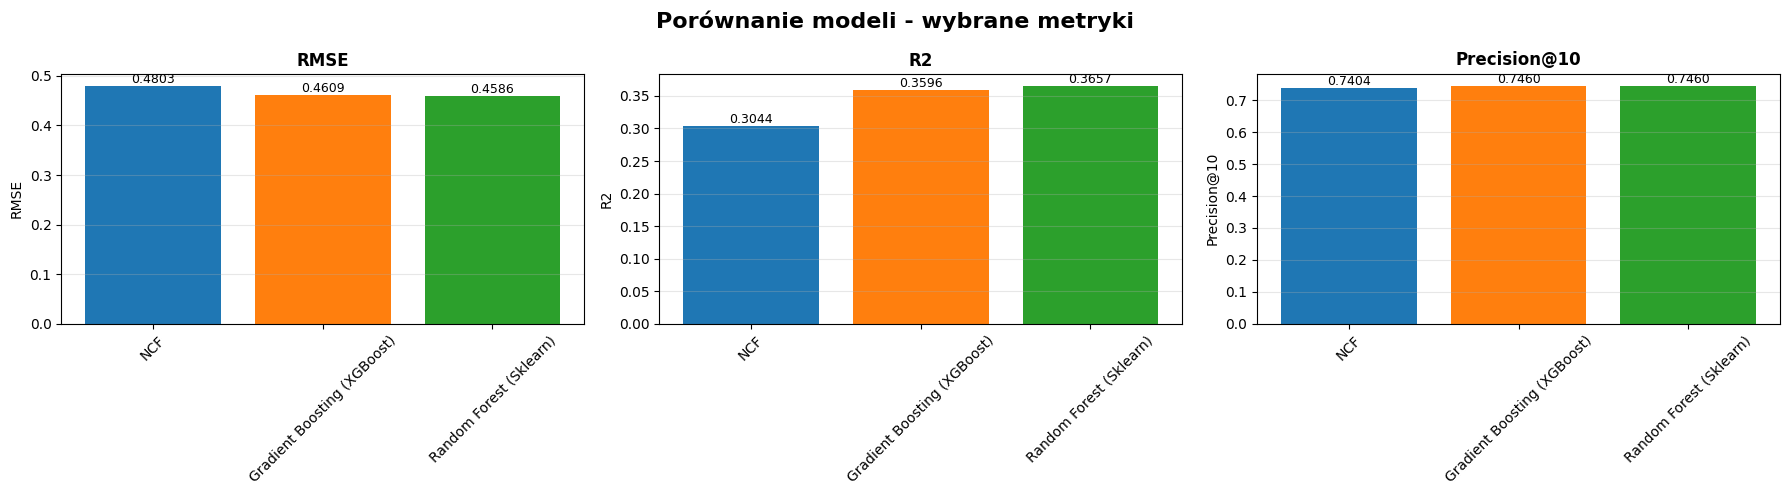

Wyniki zapisane do 'model_metrics.csv'


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Porównanie modeli - wybrane metryki', fontsize=16, fontweight='bold')

for idx, metric in enumerate(['RMSE', 'R2', 'Precision@10']):
    ax     = axes[idx]
    values = results_df[metric].values
    models = results_df.index.values
    bars   = ax.bar(models, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("Wykres zapisany jako 'model_comparison.png'")
plt.show()

results_df.to_csv('model_metrics.csv')
print("Wyniki zapisane do 'model_metrics.csv'")

In [43]:
import pandas as pd

# Zbieramy wszystkie wyniki w jedną listę
all_results = [
    metrics_xgb_raw,    # XGBoost na surowych ID
    metrics_rf_raw,     # Random Forest na surowych ID
    metrics_ncf,        # Czysty NCF (Deep Learning)
    metrics_gb,         # Hybryda: XGBoost + NCF Embs
    metrics_rf,         # Hybryda: RF + NCF Embs
    metrics_rp3_local   # RP3beta (Lokalny ranking)
]

# Tworzymy DataFrame
final_table = pd.DataFrame(all_results)

# Zaokrąglamy wyniki dla lepszej czytelności
final_table = final_table.round(4)

# Wyświetlamy tabelę posortowaną po NDCG (najlepsza metryka jakości rankingu)
print("FINALNE ZESTAWIENIE MODELI")
display(final_table.sort_values(by='NDCG@10', ascending=False))

FINALNE ZESTAWIENIE MODELI


,Model,RMSE,MAE,R2,Precision@10,Recall@10,NDCG@10,Precision@5,Recall@5,NDCG@5,Coverage
3,Gradient Boosting (XGBoost),0.4609,0.3463,0.3596,0.7460,0.9191,0.9847,0.7721,0.8299,0.9816,0.000
4,Random Forest (Sklearn),0.4586,0.3442,0.3657,0.7460,0.9187,0.9844,0.7706,0.8296,0.9811,0.000
2,NCF,0.4803,0.3650,0.3044,0.7404,0.9128,0.9827,0.7675,0.8251,0.9800,0.959
1,Random Forest Raw,0.5235,0.4059,0.1736,0.7215,0.8902,0.9764,NaN,NaN,NaN,NaN
0,XGBoost Raw,0.5201,0.3973,0.1843,0.7254,0.8960,0.9761,NaN,NaN,NaN,NaN
5,RP3β (Graph),NaN,NaN,NaN,0.6975,0.8661,0.9538,NaN,NaN,NaN,NaN


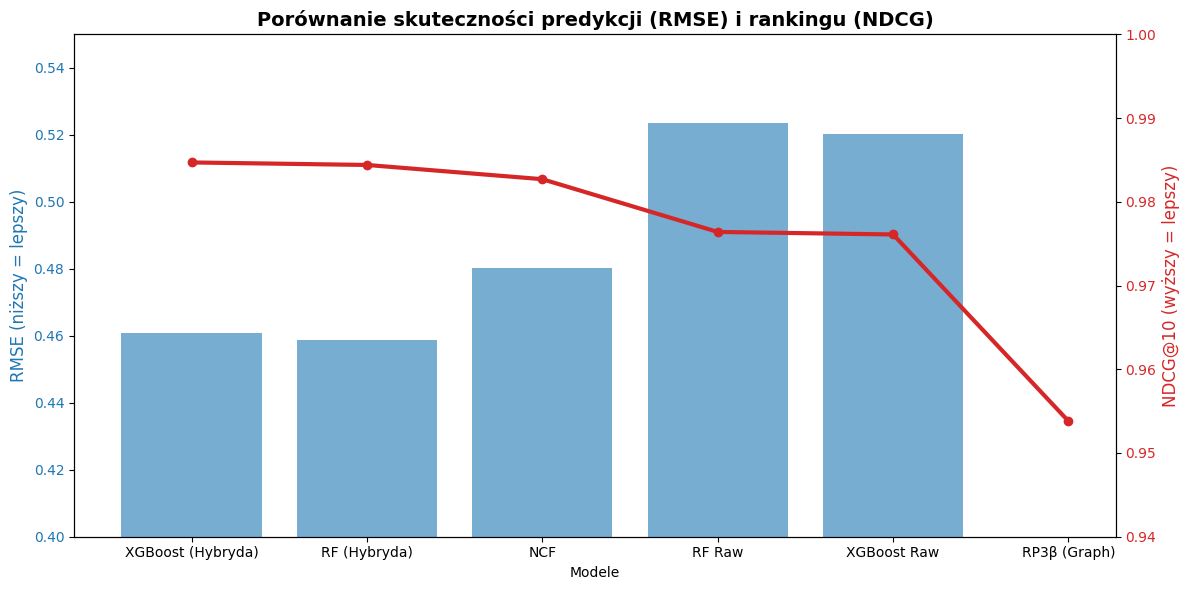

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Dane z Twojej tabeli
data = {
    'Model': ['XGBoost (Hybryda)', 'RF (Hybryda)', 'NCF', 'RF Raw', 'XGBoost Raw', 'RP3β (Graph)'],
    'RMSE': [0.4609, 0.4586, 0.4803, 0.5235, 0.5201, np.nan],
    'NDCG@10': [0.9847, 0.9844, 0.9827, 0.9764, 0.9761, 0.9538]
}

df_plot = pd.DataFrame(data)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Wykres słupkowy dla RMSE
color1 = 'tab:blue'
ax1.set_xlabel('Modele')
ax1.set_ylabel('RMSE (niższy = lepszy)', color=color1, fontsize=12)
bars = ax1.bar(df_plot['Model'], df_plot['RMSE'], color=color1, alpha=0.6, label='RMSE')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0.4, 0.55) # Skupienie na różnicach

# Druga oś dla NDCG
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('NDCG@10 (wyższy = lepszy)', color=color2, fontsize=12)
ax2.plot(df_plot['Model'], df_plot['NDCG@10'], color=color2, marker='o', linewidth=3, label='NDCG@10')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0.94, 1.0)

plt.title('Porównanie skuteczności predykcji (RMSE) i rankingu (NDCG)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.xticks(rotation=45)
plt.show()